In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("../data/sample_car_contracts.csv")
df.head()

,id,customer_name,contract_type,vehicle_type,monthly_emi,interest_rate,tenure_months,clause_summary,risk_flag,issue_type,recommended_action
0,1,Rahul Mehta,Car Loan,Sedan,18500,9.5,48,Prepayment allowed only after 24 months with 5...,medium,High prepayment charges,Highlight prepayment penalty to user and sugge...
1,2,Anita Rao,Car Lease,SUV,22000,0.0,36,Lessee must pay for all maintenance and insurance,low,Standard maintenance clause,"No action, just explain maintenance responsibi..."
2,3,James Wilson,Car Loan,Hatchback,14500,11.2,60,Late payment fee of 3% per month on outstandin...,high,Aggressive late fee,Flag clause and suggest user request cap on la...
3,4,Meena Iyer,Car Lease,Sedan,21000,0.0,24,"Excess mileage charge of ₹12 per km over 15,00...",medium,High excess mileage rate,Warn user about extra mileage charges and reco...
4,5,Arjun Patel,Car Loan,SUV,27500,10.8,72,Floating interest rate linked to lender's inte...,high,Unclear interest benchmark,Explain floating rate risk and suggest asking ...



🔹 TOP KEYWORDS IN HIGH-RISK CONTRACTS:

of             2
fee            2
to             2
payment        1
3%             1
per            1
month          1
on             1
outstanding    1
amount         1
Name: count, dtype: int64


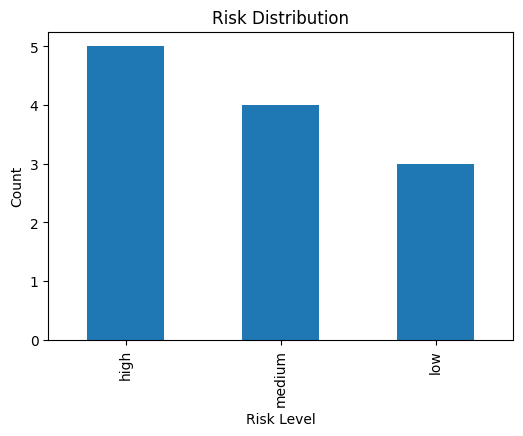


🔹 FINAL DATAFRAME WITH NEW COLUMNS:

   id customer_name contract_type vehicle_type  monthly_emi  interest_rate  \
0   1   Rahul Mehta      Car Loan        Sedan        18500            9.5   
1   2     Anita Rao     Car Lease          SUV        22000            0.0   
2   3  James Wilson      Car Loan    Hatchback        14500           11.2   
3   4    Meena Iyer     Car Lease        Sedan        21000            0.0   
4   5   Arjun Patel      Car Loan          SUV        27500           10.8   
5   6     Sana Khan     Car Lease    Hatchback        16500            0.0   
6   7   Vikram Shah      Car Loan        Sedan        19500            8.9   
7   8    Neha Singh     Car Lease           EV        25500            0.0   
8   9     David Roy      Car Loan          SUV        30500           12.5   
9  10   Kiran Kumar     Car Lease        Sedan        18500            0.0   

   tenure_months                                     clause_summary risk_flag  \
0             48  Prep

In [2]:
df["contract_length"] = df["clause_summary"].astype(str).apply(lambda x: len(x.split()))

hidden_words = ["fee", "penalty", "late", "extra", "charge", "excess"]

df["hidden_charges_flag"] = df["clause_summary"].str.lower().apply(
    lambda text: any(word in text for word in hidden_words)
)

high_text = " ".join(df[df["risk_flag"] == "high"]["clause_summary"]).lower()
word_list = high_text.split()
word_freq = pd.Series(word_list).value_counts()

print("\n🔹 TOP KEYWORDS IN HIGH-RISK CONTRACTS:\n")
print(word_freq.head(10))

#  Plot Risk Distribution
plt.figure(figsize=(6,4))
df["risk_flag"].value_counts().plot(kind="bar")
plt.title("Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

print("\n🔹 FINAL DATAFRAME WITH NEW COLUMNS:\n")
print(df.head(10))


In [6]:
import pandas as pd

df = pd.read_csv("../data/sample_car_contracts.csv")
df["contract_length"] = df["clause_summary"].astype(str).apply(lambda x: len(x.split()))

print(df[["clause_summary", "contract_length"]])


                                       clause_summary  contract_length
0   Prepayment allowed only after 24 months with 5...                9
1   Lessee must pay for all maintenance and insurance                8
2   Late payment fee of 3% per month on outstandin...               10
3   Excess mileage charge of ₹12 per km over 15,00...               12
4   Floating interest rate linked to lender's inte...                8
5      Early termination fee equal to 6 months of EMI                9
6              No foreclosure charges after 12 months                6
7   Battery warranty covered only for 24 months or...               10
8   Mandatory bundled insurance from lender at non...                8
9   Security deposit of 3 EMIs, refundable at end ...               14
10  Processing fee of 1.5% of loan amount, non-ref...                8
11  Lessor can repossess vehicle after 2 consecuti...               12
